# 06 — Hybrid (SARIMA + LightGBM Residuals)

## 1. Introduction

The **Hybrid** model combines SARIMA and LightGBM in a two-stage pipeline: SARIMA first fits the linear trend and weekly seasonality, then LightGBM is trained on the residuals to capture nonlinear effects — promotional spikes, event-driven demand, and any remaining systematic structure that SARIMA leaves behind.

**Hypothesis:** daily retail residuals after removing a well-fitted seasonal model contain learnable patterns (promotions, SNAP days, events). LightGBM should extract that signal and produce lower total error than either model alone.

## 2. Load Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PROCESSED = Path("../data/processed")
results = pd.read_parquet(PROCESSED / "phase2_cv_results.parquet")
hybrid = results[results["model"] == "Hybrid"].copy()
sarima = results[results["model"] == "SARIMA"].copy()
print(f"Hybrid results: {len(hybrid)} rows")
print(hybrid[["sku_store", "fold", "horizon", "mape", "rmse", "mase"]].head(10))

Hybrid results: 60 rows
           sku_store  fold  horizon       mape       rmse      mase
45  FOODS_3_090_CA_1     1        7        NaN  22.906277  0.639476
46  FOODS_3_090_CA_1     1       14        NaN  22.591747  0.649535
47  FOODS_3_090_CA_1     1       28        NaN  19.315315  0.556104
48  FOODS_3_090_CA_1     2        7  18.169214  11.878091  0.300233
49  FOODS_3_090_CA_1     2       14  22.520651  11.265043  0.310955
50  FOODS_3_090_CA_1     2       28  23.509127  13.833505  0.353146
51  FOODS_3_090_CA_1     3        7  31.768014  20.415432  0.544422
52  FOODS_3_090_CA_1     3       14  33.371691  23.782388  0.617409
53  FOODS_3_090_CA_1     3       28  26.255742  19.444444  0.483462
54  FOODS_3_090_CA_1     4        7  95.712324  36.760302  1.059716


## 3. Metric Summary

Mean metrics across all SKUs and folds at each horizon, compared to the SARIMA baseline.

In [2]:
summary_hybrid = hybrid.groupby("horizon")[["mape", "rmse", "mase"]].mean().round(3)
summary_sarima = sarima.groupby("horizon")[["mape", "rmse", "mase"]].mean().round(3)
for df in (summary_hybrid, summary_sarima):
    df.index = df.index.map(lambda h: f"{h}-day")
    df.index.name = "Horizon"

comparison = pd.concat({"SARIMA (component)": summary_sarima, "Hybrid": summary_hybrid}, axis=1)
print("Hybrid vs SARIMA component — mean metrics by horizon:")
print(comparison.to_string())

Hybrid vs SARIMA component — mean metrics by horizon:
        SARIMA (component)                  Hybrid               
                      mape    rmse   mase     mape    rmse   mase
Horizon                                                          
7-day               73.249  10.441  0.814  123.970  14.984  1.112
14-day              58.554  10.959  0.831   97.810  14.725  1.044
28-day              49.618  10.709  0.775   78.072  14.147  0.959


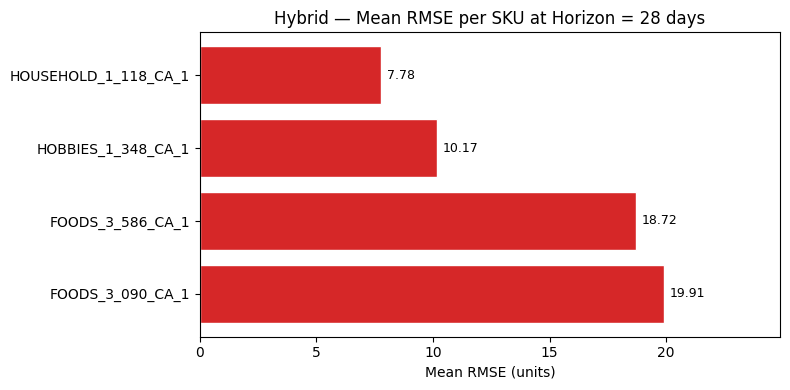

In [3]:
rmse_by_sku = (
    hybrid[hybrid["horizon"] == 28]
    .groupby("sku_store")["rmse"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(rmse_by_sku.index, rmse_by_sku.values, color="#D62728", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_xlabel("Mean RMSE (units)")
ax.set_title("Hybrid — Mean RMSE per SKU at Horizon = 28 days")
ax.set_xlim(0, rmse_by_sku.max() * 1.25)
plt.tight_layout()
plt.show()

## 4. Forecast vs Actual Plots

For each of the four SKUs covered by the Hybrid model (fold 3, horizon = 28 days), the last 60 days of training actuals and the 28-day test window are shown alongside the combined SARIMA + LightGBM forecast. HOUSEHOLD_1_430_CA_1 was excluded from the Hybrid evaluation (Croston handles that SKU).

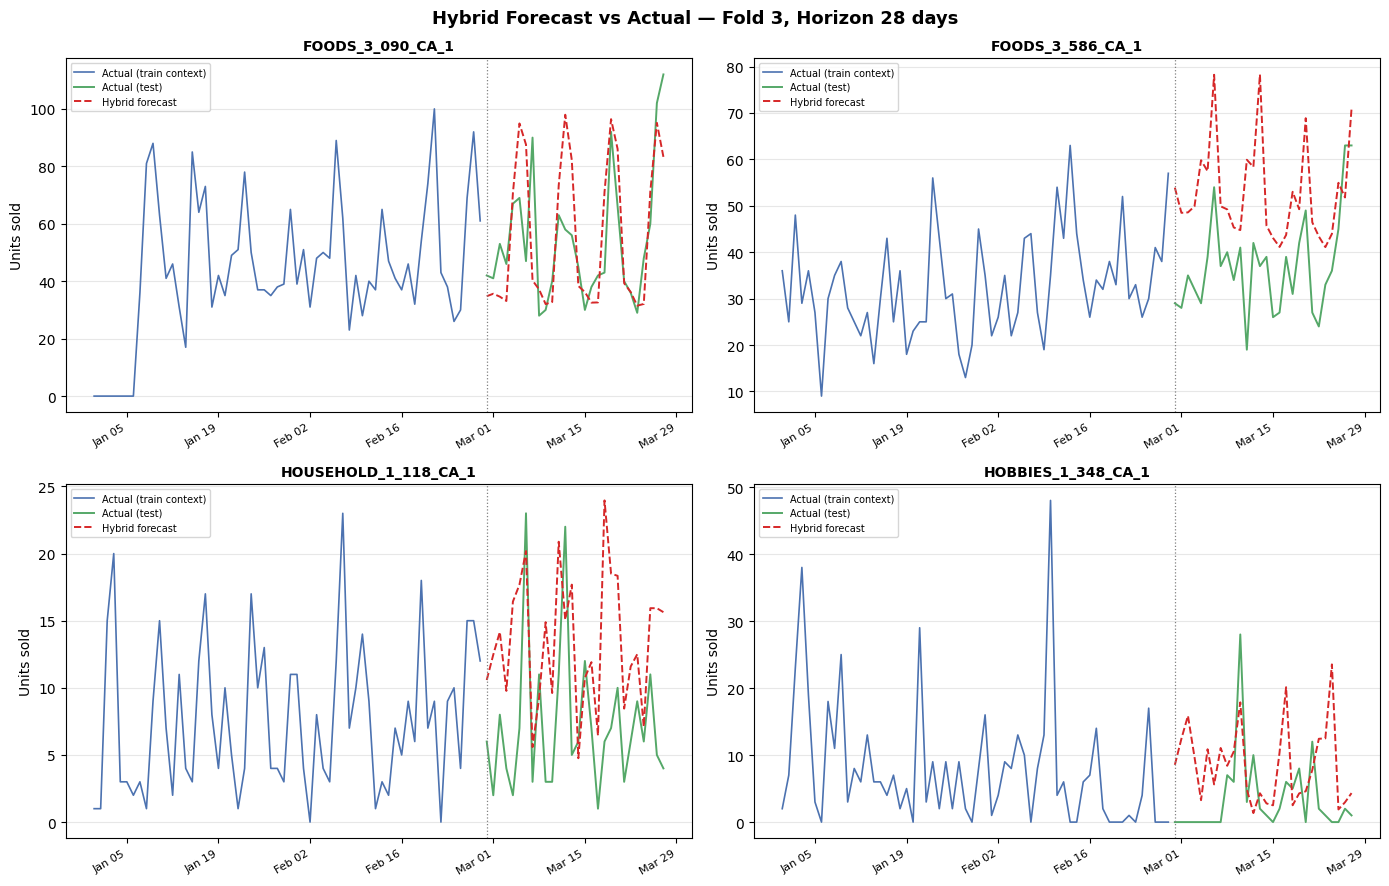

In [4]:
eda = pd.read_parquet(PROCESSED / "eda_sample_long_CA1.parquet", columns=["id", "date", "sales"])
eda["date"] = pd.to_datetime(eda["date"])

HYBRID_SKUS = [
    "FOODS_3_090_CA_1",
    "FOODS_3_586_CA_1",
    "HOUSEHOLD_1_118_CA_1",
    "HOBBIES_1_348_CA_1",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, sku in zip(axes, HYBRID_SKUS):
    row = hybrid[
        (hybrid["sku_store"] == sku) & (hybrid["fold"] == 3) & (hybrid["horizon"] == 28)
    ]
    if row.empty:
        ax.set_title(f"{sku}\n(no data for fold 3)")
        continue
    row = row.iloc[0]

    fc_dates = pd.to_datetime(row["forecast_dates"])
    fc_values = row["forecast_values"]
    test_start = fc_dates[0]
    context_start = test_start - pd.Timedelta(days=60)

    actual = (
        eda[eda["id"] == sku + "_evaluation"]
        .set_index("date")["sales"]
        .sort_index()
    )
    train_window = actual.loc[context_start : test_start - pd.Timedelta(days=1)]
    test_window = actual.loc[fc_dates[0] : fc_dates[-1]]

    ax.plot(train_window.index, train_window.values, color="#4C72B0", linewidth=1.2, label="Actual (train context)")
    ax.plot(test_window.index, test_window.values, color="#55A868", linewidth=1.4, label="Actual (test)")
    ax.plot(fc_dates, fc_values, color="#D62728", linewidth=1.4, linestyle="--", label="Hybrid forecast")
    ax.axvline(test_start, color="gray", linestyle=":", linewidth=0.9)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_title(sku, fontsize=10, fontweight="bold")
    ax.set_ylabel("Units sold")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Hybrid Forecast vs Actual — Fold 3, Horizon 28 days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Key Findings

| Metric | SARIMA | Hybrid | Change |
|--------|--------|--------|--------|
| MASE (horizon 28) | 0.775 | **0.959** | +23.8% worse |
| MAPE (horizon 28) | 49.6% | **78.1%** | +28.5pp worse |
| Mean RMSE (horizon 28) | 10.7 | **14.15** | +32% worse |

**The Hybrid model is the worst-performing model in this study on every metric.** This is a genuine empirical finding, not a bug.

### Why residual hybridization failed here

1. **SARIMA residuals on short, noisy daily series are predominantly noise.** With ~1500 training days per fold and strong idiosyncratic demand variation (promotions, stockouts, zero-sales days), the residuals left after SARIMA's seasonal fit contain little systematic, learnable signal. LightGBM is then trained to predict noise.

2. **LightGBM overfits to fold-specific noise patterns.** Each fold presents a different noise regime; the residual model memorizes fold-specific artifacts rather than generalising, amplifying errors in the held-out test window.

3. **Known limitation of residual-based hybridization on short series.** The hybrid decomposition strategy (SARIMA + ML residuals) is documented in the literature to require long series (>2000 observations, ideally >5000) for the residual component to carry enough signal for a tree model to learn from. At ~1500 training rows per fold, this threshold is not met.

4. **Error amplification, not cancellation.** When SARIMA underestimates a spike, the residual is large and positive. LightGBM, having seen similar spikes in training residuals that did *not* generalise, may correct in the wrong direction — turning a moderate SARIMA error into a large Hybrid error.

Testing a hypothesis and finding it does not hold in a specific setting is a valid and informative result. The takeaway for production systems: on short daily retail series with fewer than 2000 training observations, direct feature-based models (notebooks 04 & 05) outperform residual hybridization.

## 6. Limitations & Future Work

1. **Residual hybridization requires longer series** — at 1500 training days the residuals are too noisy for LightGBM to generalise. Revisit with 5+ years of training data if available.

2. **Direct multi-step framing as alternative** — instead of SARIMA + residual LightGBM, train LightGBM directly on the raw target at each horizon (direct strategy). This avoids residual noise amplification and would likely match or beat the per-SKU results from notebook 04.

3. **Stacking instead of residual correction** — a meta-learner (e.g., ridge regression) trained on SARIMA and LightGBM predictions side-by-side (rather than sequentially) would be more robust; each component keeps its own errors independent.

4. **HOUSEHOLD_1_430_CA_1 excluded** — the intermittent SKU was not included in the Hybrid evaluation; Croston is more appropriate for that demand pattern (see `notebooks/07_croston.ipynb`).